# CNN LSTM - Cadre methodologique modulaire

Ce notebook applique un cadre methodologique reproductible et modulaire avec un modele CNN LSTM.

Il permet de :
- definir des profils (donnees, pretraitement, representation, modele, evaluation),
- executer une pipeline coherente,
- produire une fiche modele avec metriques et sorties graphiques.

In [1]:
import importlib
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.extract import add_target, load_features_for_approach
from pipeline.pretraitement import (
    apply_preprocess,
    apply_target_discretization,
    prepare_splits_and_impute,
    display_target_info
)
from pipeline.visu_pretraitement import (
    plot_feature_report,
    plot_preprocessing_report_by_approach,
    plot_split_report,
)
from pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_feature_importance,
    plot_pca_if_classification,
    train_with_optional_hyperparameter_search
)
from pipeline.reporting import export_visual_report

import pipeline.extract as _extract
import pipeline.pretraitement as _pretraitement
import pipeline.models as _models
import pipeline.evaluation as _evaluation
import pipeline.reporting as _reporting

importlib.reload(_extract)
importlib.reload(_pretraitement)
importlib.reload(_models)
importlib.reload(_evaluation)
importlib.reload(_reporting)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

Seed globale: 42


## 1) Profils modulaires

In [2]:

# Ajuster ces profils pour chaque experience
# Template source: pipeline/config.md (markdown a copier-coller)

DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Données brutes/DataPhase1_time.csv",
    "subject_id_col": "Participant",
    "time_col": "Time",
}

PREPROCESS_PROFILE = {
    "approach": "B", # "A" (indicateurs) ou "B" (temporel)
    "use_frequency_resampling": True,
    # Methode de reechantillonnage:
    # - "uniform_time_step": uniformise uniquement le pas temporel (interpolation)
    # - "lomb_scargle": reconstruction harmonique sur frequence(s) cible(s)
    "frequency_resampling_method": "uniform_time_step",
    # Pas temporel cible en secondes. None => mediane des deltas observes.
    "uniform_time_step_s": 1,

    # Fenetrage temporel: chaque echantillon represente une fenetre de cette duree.
    # Le chevauchement peut etre defini soit en secondes, soit en ratio.
    # 'post_preprocess' applique le fenetrage apres include_features, clipping et filtres.
    "window_stage": "post_preprocess",
    "window_duration_s": 60.0,
    "window_overlap_s": 0.0,
    # "window_overlap_ratio": 0.5,

    # Utilise uniquement si frequency_resampling_method == "lomb_scargle".
    # "frequency_sampling_hz": [0.1, 0.4],

    # Filtrage passe-bas
    "apply_temporal_lowpass": False,
    "lowpass_cutoff_hz": 0.2,
    "lowpass_order": 4,
    "lowpass_min_points": 16,
    "lowpass_features": "all",  # "all" ou liste explicite de features

    # Filtre passe-haut
    "apply_temporal_highpass": True,
    "highpass_cutoff_hz": 0.08,
    "highpass_order": 4,
    "highpass_min_points": 16,
    "highpass_features": [
        "HMDPosX",
        "HMDPosY",
        "HMDPosZ",
        "RotX",
        "RotY",
        "RotZ",
        "X gaze direction",
        "Y gaze direction",
    ],  # "all" ou liste de noms

    # Filtrage passe-bande
    "apply_temporal_bandpass": False,
    "bandpass_ranges_hz": [
        [0.08, 0.12],
        [0.38, 0.42],
    ],
    "bandpass_order": 4,
    "bandpass_min_points": 16,
    "bandpass_features": [
        "HMDPosX",
        "HMDPosY",
        "HMDPosZ",
        "RotX",
        "RotY",
        "RotZ",
        "X gaze direction",
        "Y gaze direction",
    ],

    # "clip_quantiles": [0.05, 0.95],   # clip sur les features
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
    "normalization": "standard",  # None / "standard" / "minmax"
    
    "time_col": "time",
    "time_unit": "s",
    "subject_id_col": "subject_id",
    # Colonnes a exclure des features (insensible a la casse)
    "exclude_features": ["minute", "time", "sampling_hz", "row_id", "Left Pupil Diameter", "Right Pupil Diameter", "window_start", "window_end", "window_center", "window_id", "window_duration_s", "window_overlap_s"],
    # Colonnes aggrégées
    "column_aggregations": {
        "Pupil diameter AVG": {
            "columns": ["Left Pupil Diameter", "Right Pupil Diameter"],
            "strategy": "mean"
        },
    },
    # include_features : "all" ou liste de colonnes a inclure
    "include_features": [
        "HMDPosX",
        "HMDPosY",
        "HMDPosZ",
        "RotX",
        "RotY",
        "RotZ",
        "Pupil diameter AVG",
        "X gaze direction",
        "Y gaze direction",
        "isBoat",
        "X World Position",
        "Y World Position"
    ]
}

TARGET_PROFILE = {
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "subject_id_col": "Sujet",
    "target_mode": "fixed_minute",
    "target_minute": 14,
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "minute_col": "minute",
    "clip_quantiles": None,           # clip sur la cible avant discretisation (ex: [0.01, 0.99])
    "discretize": {                   # None pour regression
        "bins":   [0, 5, 10, 20],
        "labels": ["low", "medium","high"],
    },
}

MODEL_PROFILE = {
    "model_type": "cnn_lstm",        # cnn_1d / inception_time / bilstm / cnn_lstm / random_forest / xgboost
    "task_type": "classification",  # classification / regression
    "use_hyperparam_search": False,   # True = recherche des meilleurs hyperparametres / False = valeurs par defaut
    "split_method": "random",        # group / random
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

OUTPUT_PROFILE = {
    "output_dir": r"../data/outputs/cnn_lstm",
    "save_model_card": True,
    "save_visual_report": True,
    "visual_report_format": "both",  # pdf / png / both
    "visual_report_name": "highband_last-minute_2.5s_resampling_cnn_lstm",
    # "all" pour tout, ou une liste explicite de fonctions
    "visual_report_functions": [
        "visual_hypothesis_page",
        "visual_cover_page",
        "visual_model_architecture_page",
        "visual_split_report",
        "visual_metrics_table_page",
        "visual_subject_window_performance_page",
        "visual_confusion_matrix_page",
        "visual_temporal_preprocess_pages",     
        "visual_missing_values_bar",
        "visual_correlation_pages",
        "visual_violin_pages",
    ],
    "max_corr_features": 24,
    "max_violin_features": 48,
    "violin_features_per_page": 6,
    # Texte libre presente sur la page de garde du rapport visuel (optionnel)
    "hypothesis": (
        """
            Nous essayons de prédire le niveau de cybersickness ressenti par un participant à partir du score ressenti à la 14eme minute (ou dernière) au FMS (low : [0-5[, medium : [5-10[, high : [10-20]) en utilisant une architecture CNN-LSTM.
            Les features utilisées sont les signaux temporels correspondant aux mouvements et rotations de la tête et des yeux, ainsi que le diamètre pupillaire, rééchantillonnés à 10 Hz (pas temporel uniforme de 0.1 s par interpolation linéaire)..
            Les fenêtres temporelles utilisées pour l'apprentissage ont une durée de 30 secondes, avec un chevauchement de 10 secondes.
            Un filtre passe-haute est appliqué aux signaux de mouvements et rotations de la tête et des yeux pour supprimer les mouvements parasites dans la simulation, en dessous de 0.08 Hz.
            Les features sont standardisées (centrage-réduction : moyenne 0, écart-type 1, ajusté sur le train uniquement) pour le CNN LSTM.
            La variable diamètre pupillaire correspond à la moyenne des diamètres pupillaires des yeux droit et gauche.
        """
    ),
}

print("Profils charges depuis la cellule notebook (template config.py)")
print("Data source :", DATA_PROFILE["source"])
print("Modele :", MODEL_PROFILE["model_type"])
print("Tache :", MODEL_PROFILE["task_type"])
print("Hyperparam search :", MODEL_PROFILE.get("use_hyperparam_search", True))
print("Target source :", TARGET_PROFILE["source"])
print("Mode cible :", TARGET_PROFILE.get("target_mode", "n/a"))
print("Normalisation :", PREPROCESS_PROFILE.get("normalization") or "aucune")
print("Approche :", PREPROCESS_PROFILE.get("approach", "A"))
print("Use frequency resampling :", PREPROCESS_PROFILE.get("use_frequency_resampling", False))
print("Resampling method :", PREPROCESS_PROFILE.get("frequency_resampling_method", "lomb_scargle"))
print("Uniform step (s) :", PREPROCESS_PROFILE.get("uniform_time_step_s"))
print("Window duration (s) :", PREPROCESS_PROFILE.get("window_duration_s"))
print("Window overlap (s) :", PREPROCESS_PROFILE.get("window_overlap_s"))
print("Low-pass actif :", PREPROCESS_PROFILE.get("apply_temporal_lowpass", False))
print("Low-pass cutoff (Hz) :", PREPROCESS_PROFILE.get("lowpass_cutoff_hz"))
print("Band-pass actif :", PREPROCESS_PROFILE.get("apply_temporal_bandpass", False))
print(
    "Band-pass range (Hz) :",
    (
        PREPROCESS_PROFILE.get("bandpass_low_cutoff_hz"),
        PREPROCESS_PROFILE.get("bandpass_high_cutoff_hz"),
    ),
)
print("Frequency sampling (Hz) :", PREPROCESS_PROFILE.get("frequency_sampling_hz"))


Profils charges depuis la cellule notebook (template config.py)
Data source : csv
Modele : cnn_lstm
Tache : classification
Hyperparam search : False
Target source : xlsx
Mode cible : fixed_minute
Normalisation : standard
Approche : B
Use frequency resampling : True
Resampling method : uniform_time_step
Uniform step (s) : 1
Window duration (s) : 60.0
Window overlap (s) : 0.0
Low-pass actif : False
Low-pass cutoff (Hz) : 0.2
Band-pass actif : False
Band-pass range (Hz) : (None, None)
Frequency sampling (Hz) : None


## 3) Construction de representation (Approche A ou B)

In [3]:
features_df = load_features_for_approach(
    data_profile=DATA_PROFILE,
    preprocess_profile=PREPROCESS_PROFILE,
    verbose=True,
)

print("Shape:", features_df.shape)
display(features_df.head())
features_df.to_csv("../data/outputs/cnn_1d_modulaire/features_after_preprocess.csv", index=False)

Approche B activee avec uniformisation du pas temporel sur les donnees brutes.
Fenetrage differe: il sera applique apres le pretraitement (window_stage='post_preprocess').
Shape: (34345, 22)


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,X gaze direction,Y gaze direction,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id
0,0.0,-0.135810,1.138490,0.372060,0.970470,3.400700,1.448690,0.000000,0.000000,0.000000,...,-0.050000,-0.240000,0.970000,1.0,0.0,0.0,136KD7,1.0,0,0
1,1.0,-0.149499,1.134967,0.362479,1.372401,5.182843,0.446927,2.946429,-2.711429,-6.905000,...,0.007214,-0.328786,0.940000,0.0,1.0,-5.0,136KD7,1.0,0,1
2,2.0,-0.151110,1.133700,0.361120,1.768330,5.602000,0.555570,3.970000,-0.500000,6.120000,...,0.009000,-0.096000,1.000000,0.0,1.0,0.0,136KD7,1.0,0,2
3,3.0,-0.151370,1.134037,0.359813,1.636170,5.723600,0.618317,3.483333,1.966667,-3.276667,...,0.040333,-0.082333,0.996667,0.0,2.0,0.0,136KD7,1.0,0,3
4,4.0,-0.152647,1.133854,0.359376,1.626580,5.895727,0.410491,1.664667,3.641333,-0.982667,...,0.068667,-0.027733,1.000000,0.0,2.0,1.0,136KD7,1.0,0,4


## 4) Integration de la cible

In [4]:
dataset_df = add_target(features_df, TARGET_PROFILE)

print("Dataset avec cible:", dataset_df.shape)
print("Apercu colonnes:", dataset_df.columns[:10].tolist())
display(dataset_df.head())

Dataset avec cible: (32663, 23)
Apercu colonnes: ['time', 'HMDPosX', 'HMDPosY', 'HMDPosZ', 'RotX', 'RotY', 'RotZ', 'Suggested Rotation X', 'Suggested Rotation Y', 'Suggested Rotation Z']


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,Y gaze direction,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id,target
0,0.0,-0.135810,1.138490,0.372060,0.970470,3.400700,1.448690,0.000000,0.000000,0.000000,...,-0.240000,0.970000,1.0,0.0,0.0,136KD7,1.0,0,0,5.0
1,1.0,-0.149499,1.134967,0.362479,1.372401,5.182843,0.446927,2.946429,-2.711429,-6.905000,...,-0.328786,0.940000,0.0,1.0,-5.0,136KD7,1.0,0,1,5.0
2,2.0,-0.151110,1.133700,0.361120,1.768330,5.602000,0.555570,3.970000,-0.500000,6.120000,...,-0.096000,1.000000,0.0,1.0,0.0,136KD7,1.0,0,2,5.0
3,3.0,-0.151370,1.134037,0.359813,1.636170,5.723600,0.618317,3.483333,1.966667,-3.276667,...,-0.082333,0.996667,0.0,2.0,0.0,136KD7,1.0,0,3,5.0
4,4.0,-0.152647,1.133854,0.359376,1.626580,5.895727,0.410491,1.664667,3.641333,-0.982667,...,-0.027733,1.000000,0.0,2.0,1.0,136KD7,1.0,0,4,5.0


## 5) Pretraitement, split et preparation

In [5]:
dataset_df = dataset_df.copy()
task_type = str(MODEL_PROFILE.get("task_type", "classification")).lower()

# En regression, repartir d'une cible brute numerique si l'etat courant du notebook
# contient deja une cible categorielle issue d'une execution precedente.
if task_type == "regression" and not pd.api.types.is_numeric_dtype(dataset_df["target"]):
    print("Cible non numerique detectee en regression: reconstruction depuis features_df.")
    dataset_df = add_target(features_df, TARGET_PROFILE)

# La discretisation ne doit etre appliquee qu'une seule fois en classification.
if task_type == "classification":
    if pd.api.types.is_numeric_dtype(dataset_df["target"]):
        dataset_df = apply_target_discretization(dataset_df, TARGET_PROFILE)
    else:
        print("Cible deja categorielle detectee: discretisation ignoree.")
else:
    if TARGET_PROFILE.get("discretize") is not None:
        print("Mode regression detecte: la discretisation de TARGET_PROFILE est ignoree.")

if len(dataset_df) == 0:
    raise ValueError(
        "Dataset vide apres preparation de la cible. "
        "Relancer les cellules 6 puis 8 pour reconstruire les donnees brutes."
    )

display_target_info(dataset_df, MODEL_PROFILE, TARGET_PROFILE, PREPROCESS_PROFILE)

raw_df = dataset_df.copy()
PREPROCESS_PROFILE_VISU = dict(PREPROCESS_PROFILE)

already_windowed_input = any("__t" in str(c) for c in dataset_df.columns)

if not already_windowed_input:
    # 1) Dataset pour visualisations: meme pretraitement, sans fenetrage temporel.
    PREPROCESS_PROFILE_VISU["window_duration_s"] = None
    PREPROCESS_PROFILE_VISU.pop("window_overlap_s", None)
    PREPROCESS_PROFILE_VISU.pop("window_overlap_ratio", None)
    dataset_df_visu, feature_cols_visu = apply_preprocess(dataset_df.copy(), PREPROCESS_PROFILE_VISU)

    # 2) Dataset pour entrainement: profil complet, incluant fenetrage.
    dataset_df_train, feature_cols_train = apply_preprocess(dataset_df.copy(), PREPROCESS_PROFILE)
else:
    print(
        "Etat deja fenetre detecte dans cette session notebook: "
        "fallback sur le dataset courant pour eviter une double transformation. "
        "Pour separer strictement train/visu, relance depuis la cellule 6."
    )
    dataset_df_train = dataset_df.copy()
    feature_cols_train = [c for c in dataset_df_train.columns if "__t" in str(c)]
    dataset_df_visu = dataset_df_train.copy()
    feature_cols_visu = feature_cols_train.copy()

if len(dataset_df_train) == 0 or len(feature_cols_train) == 0:
    raise ValueError(
        "Dataset train vide ou sans features. "
        "Relancer les cellules 6 puis 8 pour reconstruire correctement le flux."
    )

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df_train,
    feature_cols=feature_cols_train,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp = prepared["X_val_imp"]
X_test_imp = prepared["X_test_imp"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test = prepared["y_test"]
train_idx = prepared["train_idx"]
val_idx = prepared["val_idx"]
test_idx = prepared["test_idx"]
imputer = prepared["imputer"]
scaler = prepared["scaler"]

# En regression, s'assurer que la cible est numerique pour les modeles et metriques.
if task_type == "regression":
    y_train = pd.to_numeric(pd.Series(y_train), errors="coerce").to_numpy(dtype=float)
    y_val = pd.to_numeric(pd.Series(y_val), errors="coerce").to_numpy(dtype=float)
    y_test = pd.to_numeric(pd.Series(y_test), errors="coerce").to_numpy(dtype=float)

    if np.isnan(y_train).any() or np.isnan(y_val).any() or np.isnan(y_test).any():
        raise ValueError(
            "Cible non numerique detectee en mode regression. "
            "Verifier TARGET_PROFILE et les donnees source."
        )

# Adaptation des tenseurs pour les modeles temporels deep learning.
deep_models = {"cnn_1d", "inception_time", "bilstm", "cnn_lstm"}
if MODEL_PROFILE.get("model_type") in deep_models:
    windowed_feature_cols = [c for c in feature_cols_train if "__t" in c]
    if windowed_feature_cols:
        base_feature_order = []
        step_numbers = []
        for col in windowed_feature_cols:
            base_name, step_part = col.rsplit("__t", 1)
            if base_name not in base_feature_order:
                base_feature_order.append(base_name)
            try:
                step_numbers.append(int(step_part))
            except ValueError:
                pass

        step_numbers = sorted(set(step_numbers))
        sequence_length = len(step_numbers)
        n_features = len(base_feature_order)
        ordered_window_cols = [f"{feat}__t{step:04d}" for step in step_numbers for feat in base_feature_order]
        ordered_indices = [feature_cols_train.index(col) for col in ordered_window_cols if col in feature_cols_train]

        if len(ordered_indices) != len(ordered_window_cols):
            missing = [col for col in ordered_window_cols if col not in feature_cols_train]
            raise ValueError(f"Colonnes de fenetrage manquantes: {missing}")

        X_train_imp = X_train_imp[:, ordered_indices]
        X_val_imp = X_val_imp[:, ordered_indices]
        X_test_imp = X_test_imp[:, ordered_indices]
        X_train_imp = X_train_imp.reshape((-1, sequence_length, n_features))
        X_val_imp = X_val_imp.reshape((-1, sequence_length, n_features))
        X_test_imp = X_test_imp.reshape((-1, sequence_length, n_features))
    else:
        sequence_length = X_train_imp.shape[1]
        n_features = 1

        X_train_imp = X_train_imp.reshape((-1, sequence_length, n_features))
        X_val_imp = X_val_imp.reshape((-1, sequence_length, n_features))
        X_test_imp = X_test_imp.reshape((-1, sequence_length, n_features))

    MODEL_PROFILE["n_classes"] = int(pd.Series(y_train).nunique()) if MODEL_PROFILE["task_type"] == "classification" else 1
    MODEL_PROFILE["sequence_length"] = int(sequence_length)
    MODEL_PROFILE["n_features"] = int(n_features)

# Alias conserves pour compatibilite des cellules aval (entrainement/evaluation/report).
dataset_df = dataset_df_train
feature_cols = feature_cols_train

print("\nDataset train (fenetre):", dataset_df_train.shape)
print("Features train (fenetrees):", len(feature_cols_train))
print("Dataset visu (sans fenetre):", dataset_df_visu.shape)
print("Features visu (base):", len(feature_cols_visu))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))
if scaler is not None:
    print("Normalisation appliquee:", type(scaler).__name__)
if MODEL_PROFILE.get("model_type") in deep_models:
    print("Shape train pour deep model:", X_train_imp.shape)

display(dataset_df_train.head())

Classes: ['high', 'low', 'medium']
Distribution:
target
low       15979
medium    10457
high       6227
Name: count, dtype: int64

Dataset train (fenetre): (543, 730)
Features train (fenetrees): 720
Dataset visu (sans fenetre): (32663, 24)
Features visu (base): 12
Split sizes -> train/val/test: 325 109 109
Normalisation appliquee: StandardScaler
Shape train pour deep model: (325, 60, 12)


,subject_id,window_id,window_start,window_end,window_center,window_duration_s,window_overlap_s,sampling_hz,minute,target,...,Y World Position__t0050,Y World Position__t0051,Y World Position__t0052,Y World Position__t0053,Y World Position__t0054,Y World Position__t0055,Y World Position__t0056,Y World Position__t0057,Y World Position__t0058,Y World Position__t0059
0,136KD7,0,0.0,60.0,30.0,60.0,0.0,1.0,0,low,...,-0.280702,10.0,7.243902,-3.000,-1.0,-2.000000,-1.255814,-3.000000,-2.000000,-2.000000
1,136KD7,1,60.0,120.0,90.0,60.0,0.0,1.0,1,low,...,2.000000,2.0,0.000000,0.000,0.0,-0.289017,-4.000000,-1.000000,-0.733333,-3.000000
2,136KD7,2,120.0,180.0,150.0,60.0,0.0,1.0,2,low,...,0.000000,-1.0,-4.253968,-3.000,0.0,-1.000000,-2.000000,-3.178404,-3.000000,-3.636364
3,136KD7,3,180.0,240.0,210.0,60.0,0.0,1.0,3,low,...,-1.000000,-1.0,-4.000000,-2.000,-2.0,-3.000000,-1.000000,3.000000,-2.000000,2.000000
4,136KD7,4,240.0,300.0,270.0,60.0,0.0,1.0,4,low,...,0.000000,-1.0,-3.000000,-3.125,-5.0,-5.000000,-6.000000,-4.666667,-3.000000,-5.000000


## 5.bis) Visualisation du pretraitement

=== Diagnostic temporel (Approche B) ===
Sujets raw/proc: 41 / 41
Features inspectees: ['HMDPosX', 'HMDPosY', 'HMDPosZ', 'RotX']


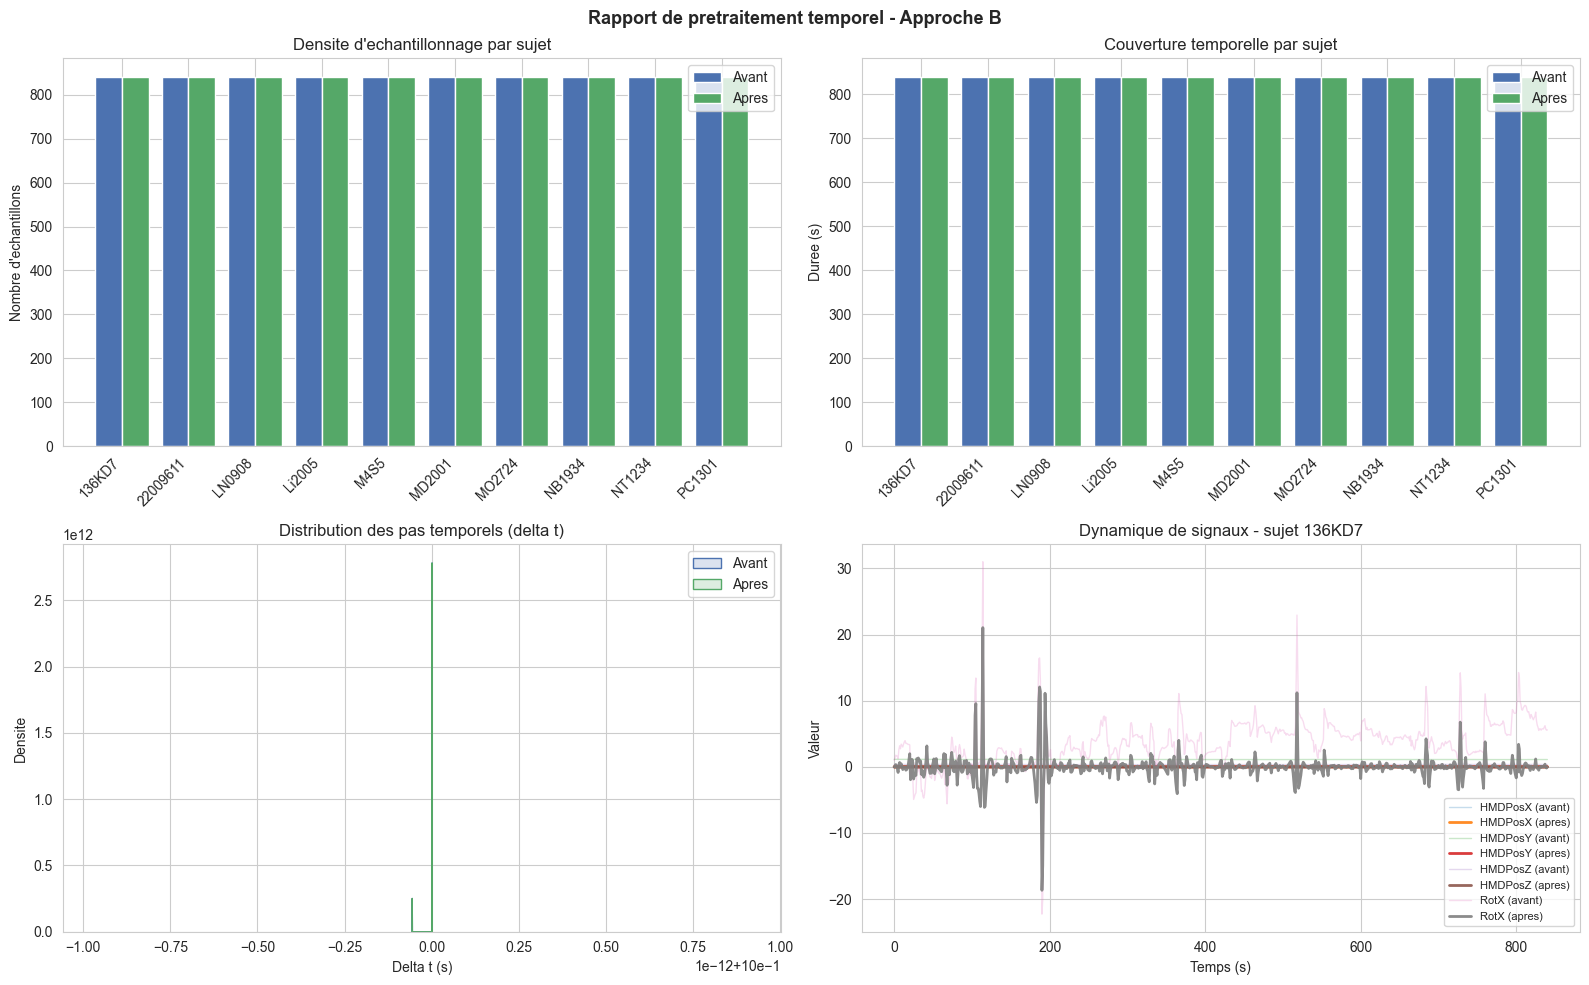

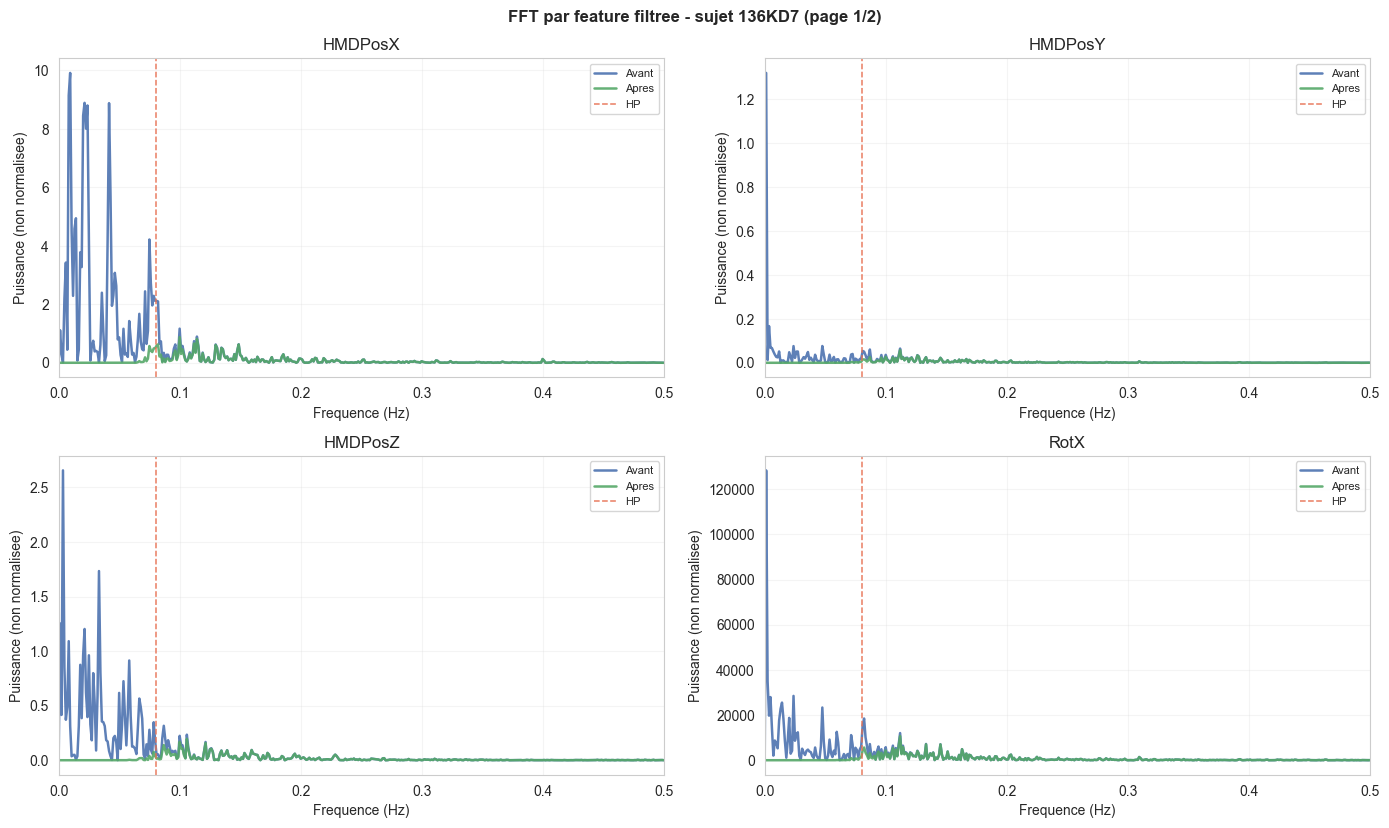

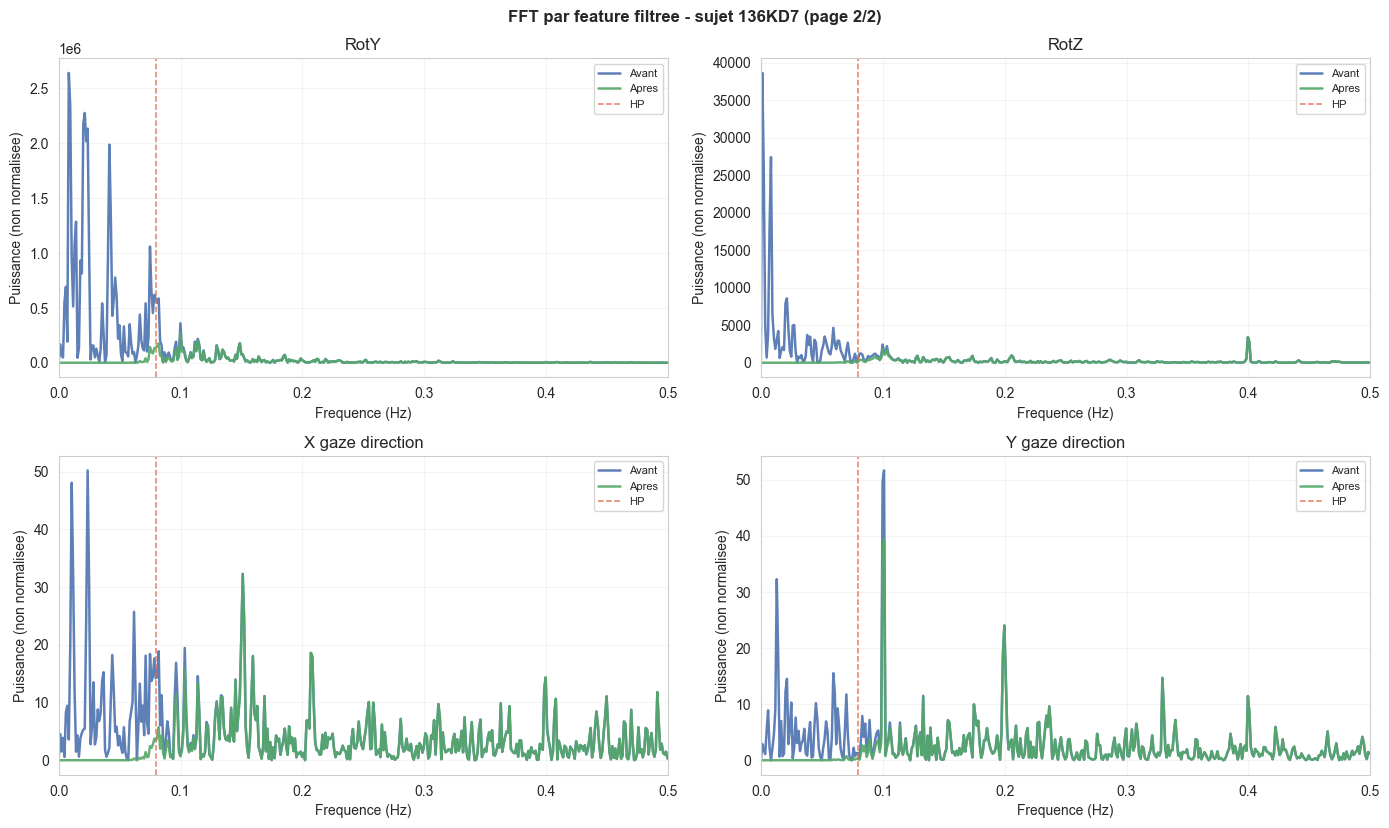

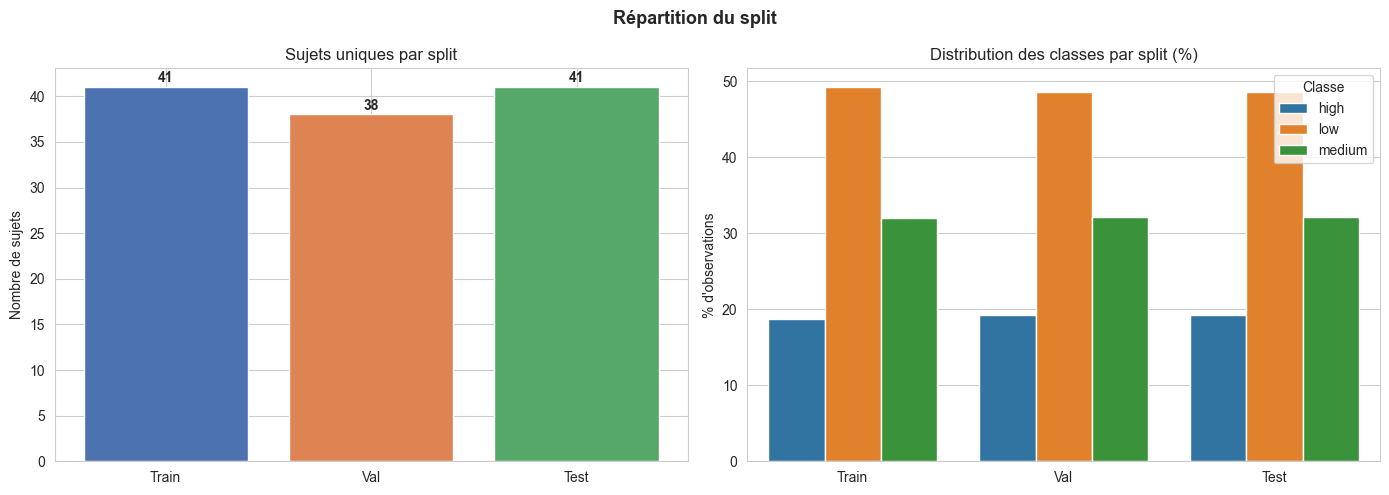

In [6]:
plot_preprocessing_report_by_approach(
    raw_df=raw_df,
    processed_df=dataset_df_visu,
    feature_cols=feature_cols_visu,
    preprocess_profile=PREPROCESS_PROFILE_VISU,
)

# Le split est celui du dataset train (fenetre), donc on garde dataset_df_train ici.
plot_split_report(dataset_df_train, train_idx, val_idx, test_idx, MODEL_PROFILE)

## 5.ter) Visualisation des features

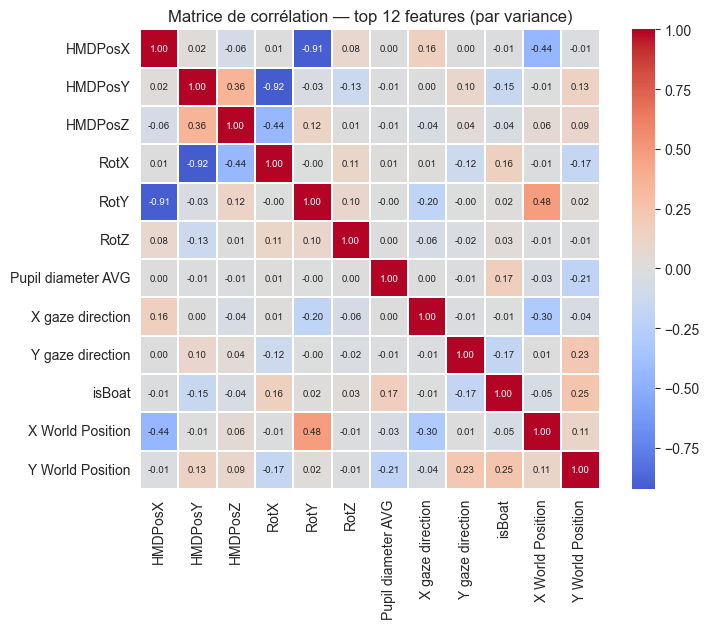

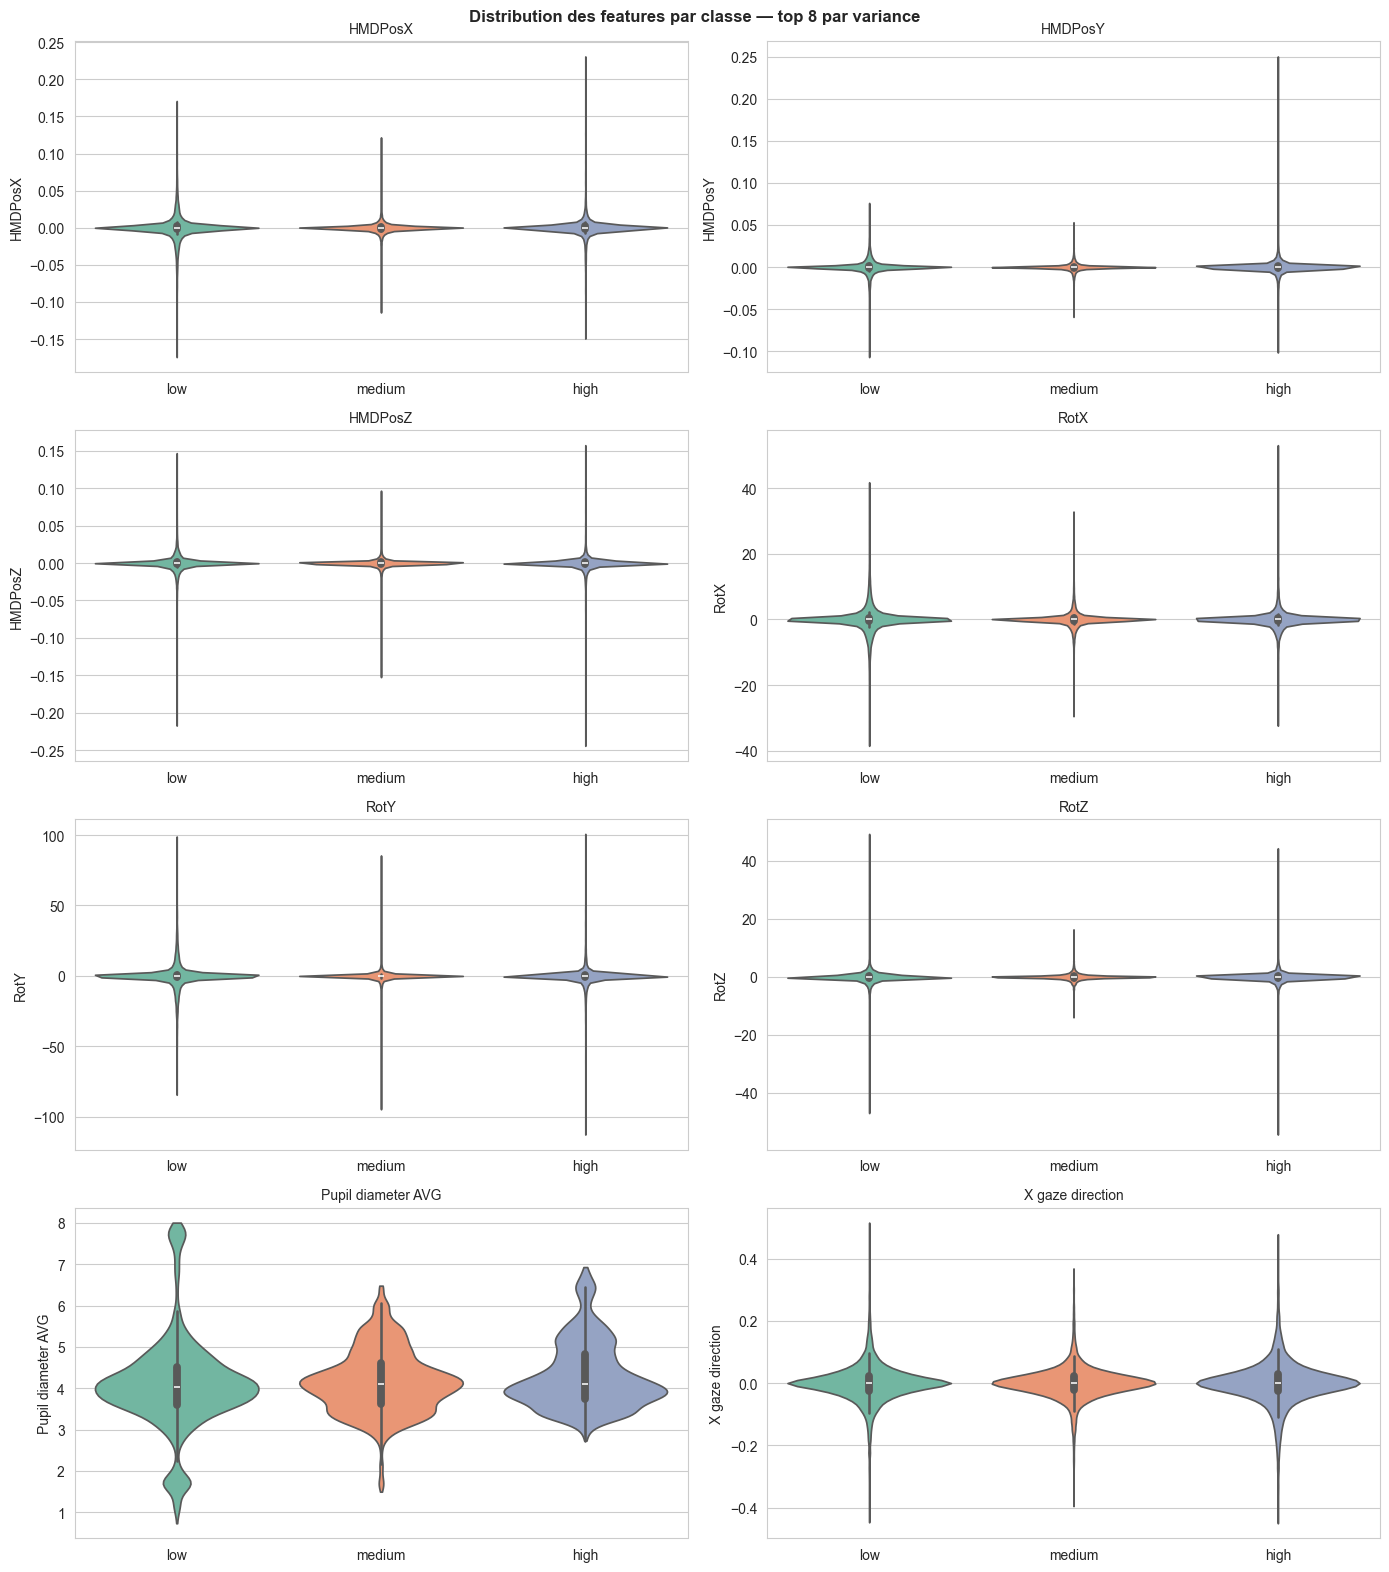

In [7]:
plot_feature_report(dataset_df_visu, feature_cols_visu, MODEL_PROFILE, target_profile=TARGET_PROFILE)

## 6) Optimisation hyperparametres et entrainement

In [8]:
deep_models = {"cnn_1d", "inception_time", "bilstm", "cnn_lstm"}
use_search = bool(MODEL_PROFILE.get("use_hyperparam_search", False))
sequence_length = X_train_imp.shape[1] if MODEL_PROFILE.get("model_type") in deep_models else None
n_features = X_train_imp.shape[2] if (MODEL_PROFILE.get("model_type") in deep_models and X_train_imp.ndim == 3) else None

final_model, best_params, results_df = train_with_optional_hyperparameter_search(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    model_profile=MODEL_PROFILE,
    approach=PREPROCESS_PROFILE.get("approach"),
    sequence_length=sequence_length,
    n_features=n_features,
)

display(results_df.head(10))
print("Best params:", best_params)

Recherche hyperparametres desactivee: utilisation des valeurs par defaut.


,mode
0,default_parameters_used


Best params: {'sequence_length': 60, 'n_features': 12}


## 7) Evaluation, robustesse et visualisations

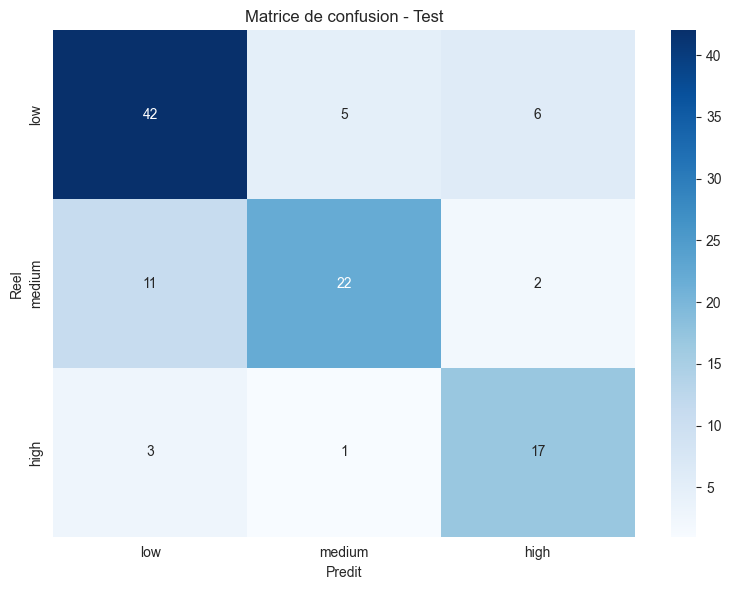

accuracy              0.743119
precision_weighted    0.747982
recall_weighted       0.743119
f1_weighted           0.741378
dtype: float64

Classification report:
              precision    recall  f1-score   support

        high       0.68      0.81      0.74        21
         low       0.75      0.79      0.77        53
      medium       0.79      0.63      0.70        35

    accuracy                           0.74       109
   macro avg       0.74      0.74      0.74       109
weighted avg       0.75      0.74      0.74       109



,subject_id,n,accuracy,f1_weighted
0,136KD7,3.0,0.666667,0.800000
1,22009611,7.0,0.571429,0.727273
2,7180bt,3.0,1.000000,1.000000
3,933,2.0,0.500000,0.666667
4,AP1133,1.0,1.000000,1.000000
5,BD1510,3.0,1.000000,1.000000
6,BM1997,1.0,0.000000,0.000000
7,CC1969,2.0,1.000000,1.000000
8,CH1308,2.0,1.000000,1.000000
9,CL1901,1.0,1.000000,1.000000


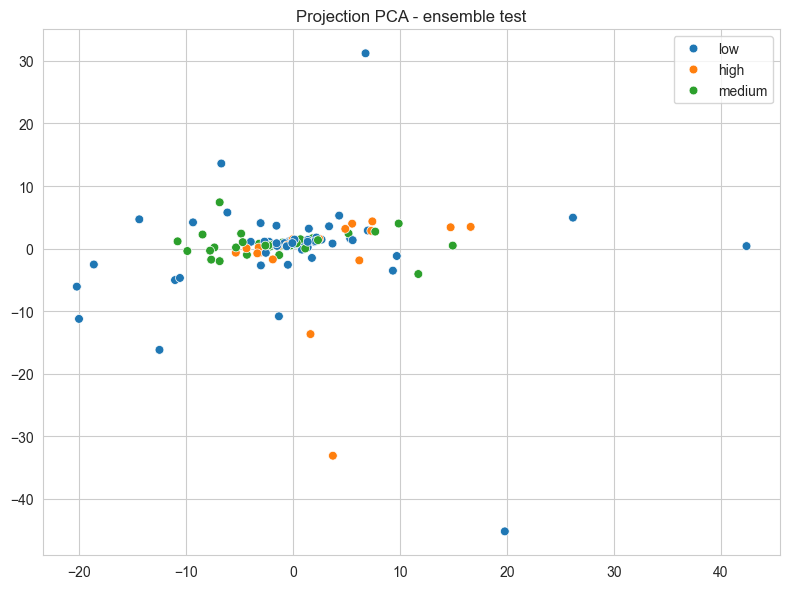

In [9]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    target_profile=TARGET_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))


imp_df = plot_feature_importance(final_model, feature_cols, top_n=15)
if imp_df is not None:
    display(imp_df.head(20))

plot_pca_if_classification(X_test_imp, y_test, MODEL_PROFILE, seed=SEED)

## 8) Fiche modele

In [10]:
export_visual_report(
    dataset_df=dataset_df_visu,
    feature_cols=feature_cols_visu,
    model_profile=MODEL_PROFILE,
    output_profile=OUTPUT_PROFILE,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    target_profile=TARGET_PROFILE,
    raw_df=raw_df,
    preprocess_profile=PREPROCESS_PROFILE_VISU,
    metrics=metrics,
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    dataset_df_train=dataset_df_train,
    feature_cols_train=feature_cols_train,
 )

{'pages': 16,
 'report_name': 'highband_last-minute_2.5s_resampling_cnn_lstm_20260529_165816',
 'pdf_path': '../data/outputs/cnn_lstm\\highband_last-minute_2.5s_resampling_cnn_lstm_20260529_165816.pdf',
 'png_dir': '../data/outputs/cnn_lstm\\highband_last-minute_2.5s_resampling_cnn_lstm_20260529_165816_png'}